In [ ]:
import import_helper
import_helper.add_models()

import mcmc.mcmc_functions as mcmc
import model.mutual_inhibition_grn as grn

import model.utils as u
import arviz as az
import scipy.stats as st

import os
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.style.use('seaborn-v0_8-bright')
plt.rcParams["font.family"] = "monospace"
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True

ModuleNotFoundError: No module named 'arviz'

### Use MCMC to infer parameters

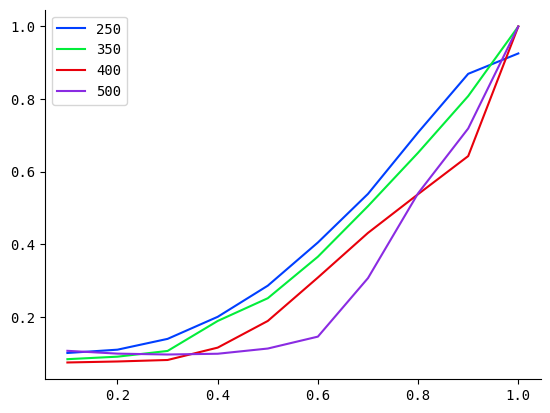

In [ ]:
# plot all circular data
radii = [250, 350, 400, 500]
radius_array = np.linspace(0, 1, 10+1)[1:]
for i in radii:
    data_path = f"../mcmc/mcmc_data/tbxt_circle_{i}um_mcmc.csv"
    dataframe = pd.read_csv(data_path)
    data = dataframe[dataframe.columns[2:]].mean(axis=1).to_numpy()
    plt.plot(radius_array, data, label=i)
plt.legend()

In [21]:
# import data and try some parameters to set priors
n_radius = 10
radius_array = np.linspace(0, 1, n_radius+1)[1:]

data_path = "../mcmc/mcmc_data/tbxt_circle_350um_mcmc.csv"
dataframe = pd.read_csv(data_path)
data = dataframe[dataframe.columns[2:]].mean(axis=1).to_numpy()
print(f"Data={data}")
data_err = dataframe[dataframe.columns[2:]].std(axis=1).to_numpy().mean()
print(f"Data Error={data_err}")
full_data =(radius_array, data, data_err)

# trying some parameters
simulation = mcmc.model((8, 1.0, 0.05, 0.18)) # plot data
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(radius_array, data, color="red")
ax.plot(radius_array, simulation, linestyle="--", color="purple")
ax.fill_between(radius_array, data-data_err, data+data_err, color="Red", alpha=0.2)
ax.set_ylim(0, 1.1)
ax.set_xlim(0, 1.1)

Data=[0.08341643 0.09030185 0.10610697 0.18868775 0.25136012 0.36570956
 0.50508237 0.65219178 0.80826831 1.        ]
Data Error=0.07207024360834771


NameError: name 'mcmc' is not defined

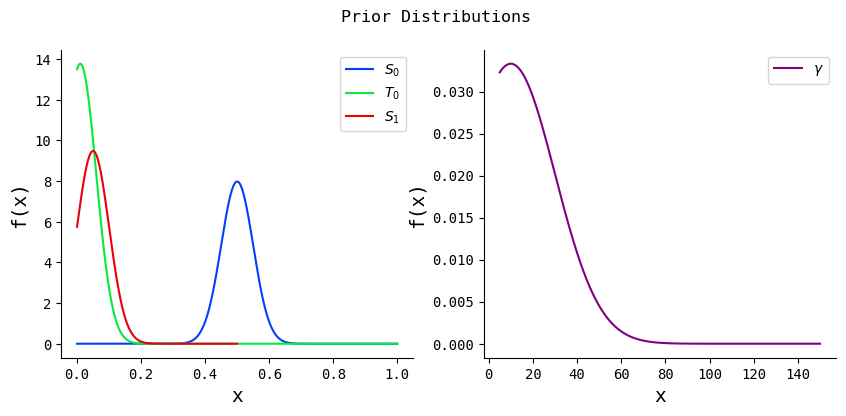

In [20]:
# plot priors to visualise
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle("Prior Distributions")

labels = [r"$S_0$", r"$T_0$", r"$S_1$"]
mus = [0.5, 0.01, 0.05] # distribution for [S0, T0, S1]
sigmas = [0.05, 0.05, 0.05]
a1, b1 = [0, 0, 0], [1, 1, 0.5]
for label, mu, sigma, a, b in zip(labels, mus, sigmas, a1, b1):
    x = np.linspace(a, b, 1000)
    an, bn = (a - mu) / sigma, (b - mu) / sigma
    pdf = st.truncnorm.pdf(x, an, bn, loc=mu, scale=sigma)
    ax[0].plot(x, pdf, label=label)
ax[0].set_xlabel('x', fontsize=14)
ax[0].set_ylabel('f(x)', fontsize=14)
ax[0].legend(loc=1)

# for gamma 
mu, sigma = 10, 20
a, b = 5, 150
x = np.linspace(5, 150, 1000)
an, bn = (a - mu) / sigma, (b - mu) / sigma
pdf = st.truncnorm.pdf(x, an, bn, loc=mu, scale=sigma)
ax[1].plot(x, pdf, label=r"$\gamma$", color="Purple")
ax[1].set_xlabel('x', fontsize=14)
ax[1].set_ylabel('f(x)', fontsize=14)
ax[1].legend(loc=1)

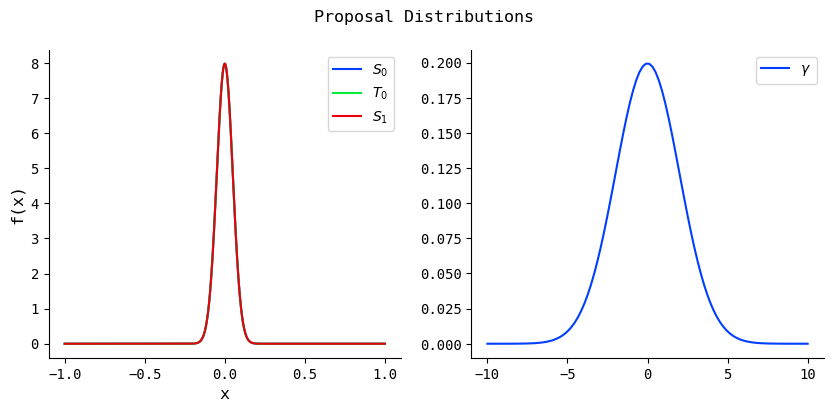

In [21]:
# plot proposal to visualise (for METROPOLIS HASTINGS ONLY )
from scipy.stats import norm
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle("Proposal Distributions")

x = np.linspace(-1, 1, 1000)
labels = [r"$S_0$", r"$T_0$", r"$S_1$"]
mus = [0, 0, 0]
sigmas = [0.05, 0.05, 0.05]
for label, mu, sigma in zip(labels, mus, sigmas):
    pdf = norm.pdf(x, mu, sigma)
    ax[0].plot(x, pdf, label=label)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('f(x)', fontsize=12)
ax[0].legend(loc=1)

# for gamma 
mu, sigma = 0, 2 #10, 10
x = np.linspace(-10, 10, 100)
pdf = norm.pdf(x, mu, sigma)
ax[1].plot(x, pdf, label=r"$\gamma$")
ax[1].legend(loc=1)

{'gamma_interval__': array(-6.69836589), 'S0_interval__': array(-0.02933194), 'T0_interval__': array(-2.17305525), 'S1_interval__': array(-1.03393325), 'gamma': array(5.17855398), 'S0': array(0.98533508), 'T0': array(0.10219637), 'S1': array(0.13116114)}


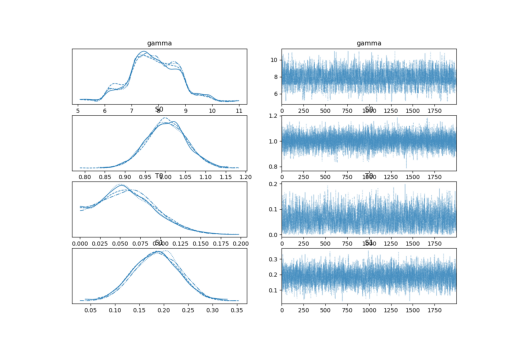

In [3]:
# read results
import matplotlib.image as mpimg
result_folder = "../mcmc_fit/350um_fit/results_1"
trace_plot_path = os.path.join(result_folder, "trace_plot.png")
trace_plot = mpimg.imread(trace_plot_path)
plt.imshow(trace_plot)
plt.axis("off")

results_path = os.path.join(result_folder, "mcmc_results.csv")
mcmc_df = pd.read_csv(results_path)

map_estimate_path = os.path.join(result_folder, "map_estimate.txt")
with open(map_estimate_path, 'r') as f:
    contents = f.read()
    print(contents)


In [4]:
# read trace information
trace_path = os.path.join(result_folder, "trace_results.nc")
# trace = az.from_netcdf(trace_path)

['gamma', 'S0', 'T0', 'S1']
[7.828766809587329, 1.0032778075077842, 0.06006770655361505, 0.18560880245275624]


(5.0, 15.0)

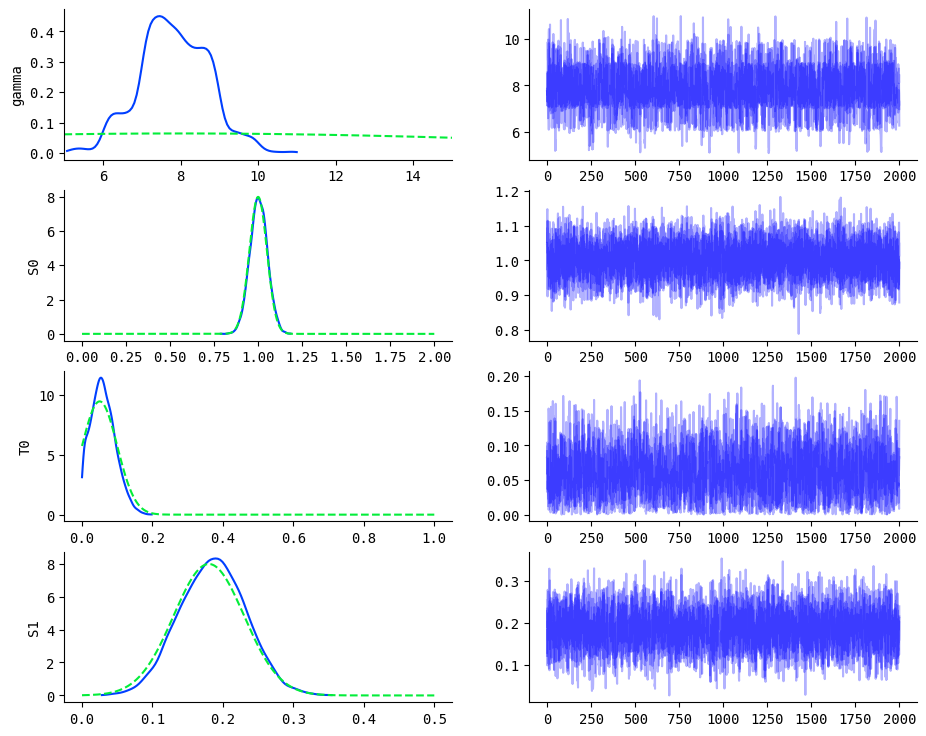

In [23]:
# analysing specific traces
from scipy.stats import gaussian_kde
selected_chains = trace.sel(chain=[0,1,2,3])
nchains = 4
sample_n = np.arange(0, 2000, 1)

# 1. Prior distribution data
mus = [8, 1.0, 0.05, 0.18]
sigmas = [10, 0.05, 0.05, 0.05]
a1, b1 = [5, 0, 0, 0], [150, 2, 1, 0.5]

# 2. Get a list of all the parameter names in the posterior
param_names = list(selected_chains.posterior.data_vars)
print(param_names)
fig, ax = plt.subplots(len(param_names), 2, figsize=(11, 9))

# 3. Loop through each parameter, flatten the selected chains, and calculate the mean
param_means = []
for i in range(len(param_names)):
    # Flatten the selected chains into a single array
    param_samples = selected_chains.posterior[param_names[i]].values
    for j in range(nchains):
        ax[i, 1].plot(sample_n, param_samples[j, :], color="Blue", alpha=0.3)

# this create the kernel, given an array it will estimate the probability over that values
    param_samples = param_samples.flatten()
    kde = gaussian_kde(param_samples)
    # these are the values over wich your kernel will be evaluated
    dist_space = np.linspace(min(param_samples), max(param_samples), 100)
    # plot the results
    ax[i, 0].plot(dist_space, kde(dist_space))

    # plot the prior
    x = np.linspace(a1[i], b1[i], 1000)
    an, bn = (a1[i] - mus[i]) / sigmas[i], (b1[i] - mus[i]) / sigmas[i]
    pdf = st.truncnorm.pdf(x, an, bn, loc=mus[i], scale=sigmas[i])
    ax[i, 0].plot(x, pdf, linestyle="--")
    ax[i, 0].set_ylabel(param_names[i])

    # Calculate the mean of the samples
    param_mean = np.mean(param_samples)
    
    # Store the mean in a dictionary
    param_means.append(param_mean)
    
    # # Plot the KDE for each parameter
    # plt.figure(figsize=(8, 6))
    # sns.kdeplot(param_samples, fill=True, color="blue")
    # plt.title(f"KDE of '{param}' (Selected Chains)")
    # plt.xlabel(param)
    # plt.ylabel("Density")
    # plt.show()

print(param_means)
args_predict = param_means
ax[0, 0].set_xlim(5, 15)

array([[<Axes: title={'center': 'gamma'}>,
        <Axes: title={'center': 'gamma'}>],
       [<Axes: title={'center': 'S0'}>, <Axes: title={'center': 'S0'}>],
       [<Axes: title={'center': 'T0'}>, <Axes: title={'center': 'T0'}>],
       [<Axes: title={'center': 'S1'}>, <Axes: title={'center': 'S1'}>]],
      dtype=object)

<Figure size 1000x2500 with 0 Axes>

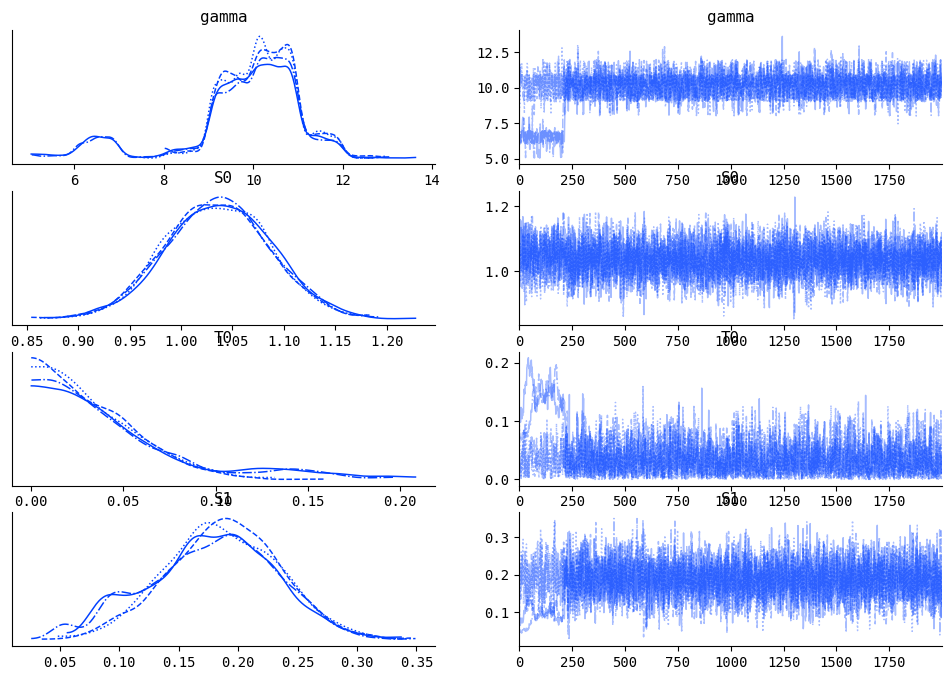

In [20]:
# nchains = 4
# samples = np.arange(0, 2000, 1)
# posterior = trace.posterior
# for i in range(nchains):
#     gamma_post = posterior["T0"].values[i, :].flatten()
#     sns.kdeplot(gamma_post, label=f"{i}")
# plt.legend()
# print(trace)
plt.figure(figsize=(10, 25))
az.plot_trace(trace)

In [5]:
mcmc_df.head()
args_predict = tuple(mcmc_df["mean"])
print(args_predict)

(7.829, 1.003, 0.06, 0.186)


### Plotting for fitted data

In [ ]:
neuruloid_diameter = 500
n_radius = 10
radius_array = np.linspace(0, 1, n_radius+1)[:-1]

# IMPORT NEURULOID DATA
data_path = f"../mcmc/mcmc_data/tbxt_circle_{neuruloid_diameter}um_mcmc.csv"
dataframe = pd.read_csv(data_path)
data = dataframe[dataframe.columns[2:]].mean(axis=1).to_numpy()
print(f"Data={data}")
data_err = dataframe[dataframe.columns[2:]].std(axis=1).to_numpy().mean()
print(f"Data Error={data_err}")
full_data =(radius_array, data, data_err)

# IMPORT MCMC DATA
result_folder = f"../mcmc/{neuruloid_diameter}um_fit/results_1"
trace_plot_path = os.path.join(result_folder, "trace_plot.png")
trace_plot = mpimg.imread(trace_plot_path)
# plt.imshow(trace_plot)
# plt.axis("off")
results_path = os.path.join(result_folder, "mcmc_results.csv")
mcmc_df = pd.read_csv(results_path)
args_predict = tuple(mcmc_df["mean"])

NameError: name 'np' is not defined

(11.523, 1.009, 0.072, 0.178)


(0.0, 1.0)

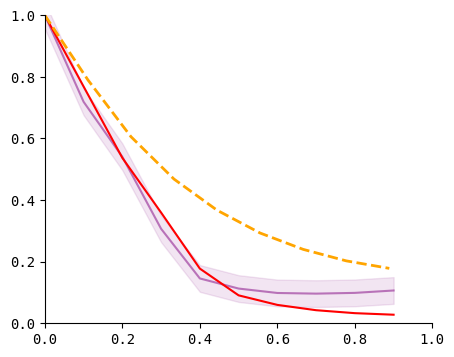

In [ ]:
# param_names = mcmc_df[mcmc_df.columns.to_list()[0]].to_list()
# args_predict = (mcmc_df.loc[i, "mean"] for i in range(len(param_names)))
print(args_predict)

wnt_simulations = pd.read_csv("../mcmc/simulation_intensity_mcmc.csv")
wnt_profile = wnt_simulations[f"gamma{int(args_predict[0])}"].to_numpy()
wnt_dist = np.linspace(0,1,len(wnt_profile))[:-1]

fitted_model = mcmc.model(args_predict)

# Plot data and fitted model
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(radius_array, 
        np.flip(data), 
        label='Observed data',
        color="Purple",
        alpha=0.5)
ax.fill_between(radius_array,
                np.flip(data+data_err),
                np.flip(data-data_err),
                color="Purple",
                alpha=0.1)
ax.plot(radius_array, 
        np.flip(fitted_model), 
        label='Fitted model', 
        color='Red')
ax.plot(wnt_dist, 
        np.flip(wnt_profile[1:]), 
        linestyle="--",
        linewidth=2, 
        color="Orange", 
        label="Fitted Wnt Profile")
ax.set_xlim(0,1)
ax.set_ylim(0, 1)
# ax.set_xlabel('Radius', fontsize=12)
# ax.set_ylabel('Intensity', fontsize=12)
# ax.legend(fontsize=12)

### Calculate the mean squared error

In [17]:
### FUNCTION TO SIMULATE GRN GIVEN WNT PROFILE
wnt_simulations = pd.read_csv("../mcmc/simulation_intensity_mcmc.csv")
def model(params):
    gamma, S0, T0, S1 = params

    # reaction_diffusion model to get Wnt profile
    wnt_profile = wnt_simulations[f"gamma{int(gamma)}"].to_numpy()
    # solve ode to get TBXT profile
    TBXT_profile = ode_model(S0, T0, S1, wnt_profile)

    return TBXT_profile

def ode_model(S0, T0, S1, A_profile):
    t_span = np.linspace(0, 10, 100)
    U0 = [0, 0.2]
    tbxt_profile = np.zeros(len(A_profile))
    for i in range(len(A_profile)):
        solution = odeint(grn.ode, U0, t_span, args=(A_profile[i], 2, 1, S0, T0, S1))
        tbxt_profile[i] = solution[-1, 0]
    return tbxt_profile

In [18]:
## FUNCTIONS TO GET MSE FROM TWO-STEP MODEL AND TBXT PROFILE
def get_mse(simulated_data, data):
    mse = np.mean((simulated_data - data)**2)
    return mse

def get_neuruloid_tbxt_data(diameter):
    data_path = f"../mcmc/mcmc_data/tbxt_circle_{diameter}um_mcmc.csv"
    dataframe = pd.read_csv(data_path)
    data = dataframe[dataframe.columns[2:]].mean(axis=1).to_numpy()
    return data

def get_mcmc_fitted_tbxt_profile(diameter):
    result_folder = f"../mcmc/mcmc_results/{diameter}um_fit/"
    results_path = os.path.join(result_folder, "mcmc_results.csv")
    mcmc_df = pd.read_csv(results_path)
    args_predict = tuple(mcmc_df["mean"])
    fitted_model = model(args_predict)
    return fitted_model

In [19]:
neuruloid_diameters = [250, 350, 400, 500]
mse_diameters_mcmc = np.zeros(len(neuruloid_diameters))
for i in range(len(neuruloid_diameters)):
    tbxt_data = get_neuruloid_tbxt_data(neuruloid_diameters[i])
    mcmc_profile = get_mcmc_fitted_tbxt_profile(neuruloid_diameters[i])
    mse_diameters_mcmc[i] = get_mse(mcmc_profile, tbxt_data)

# SAVE THE MSE NUMPY
np.save("mse_for_mcmc_fitted_tbxt.npy", mse_diameters_mcmc)

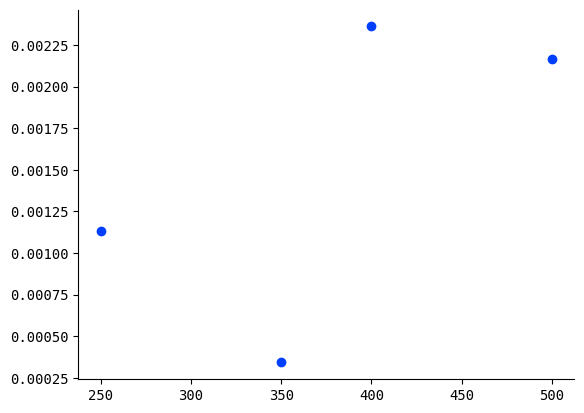

In [20]:
plt.scatter(neuruloid_diameters, mse_diameters_mcmc)